<a href="https://colab.research.google.com/github/sgevatschnaider/Teor-a-de-los-juegos/blob/main/Trump_y_la_teor%C3%ADa_de_los_juegos_sin_y_con_Payoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Niveles calculados. Máximo nivel: 4
Mostrando gráfico estático con colores por nivel:


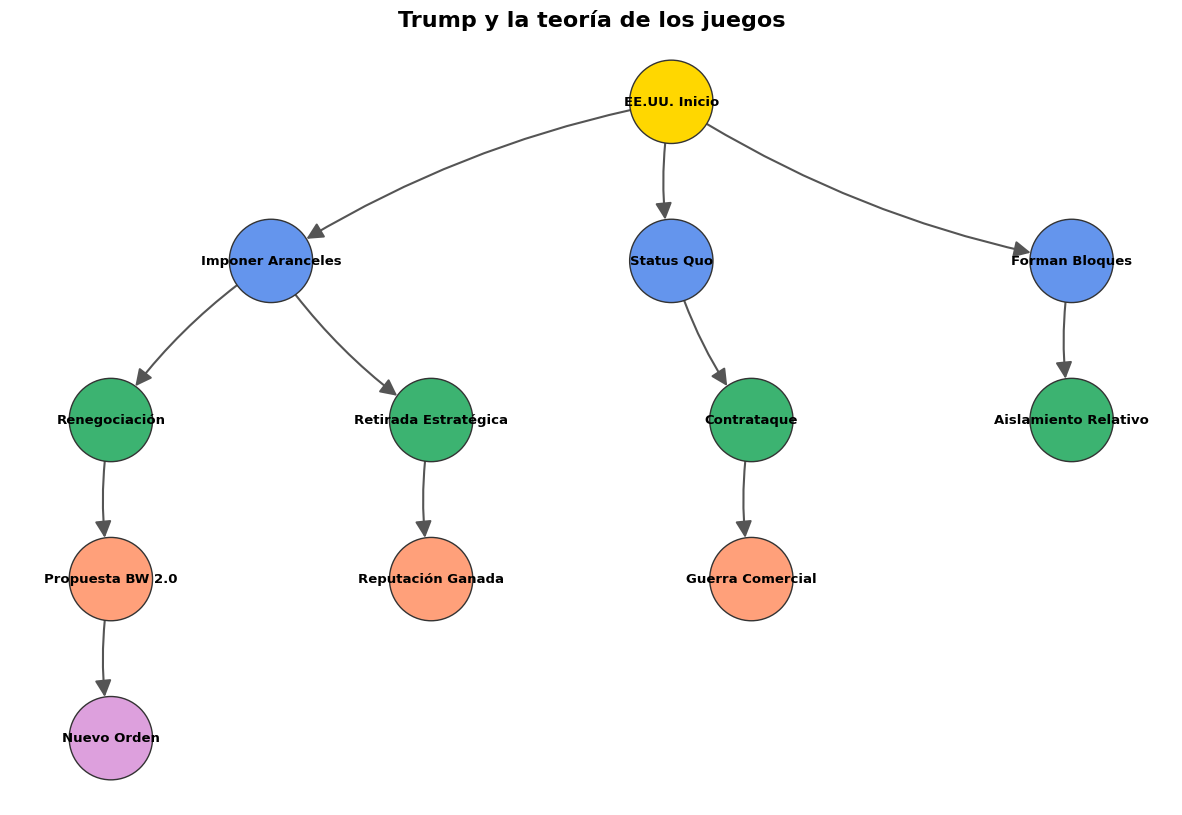


Creando animación con colores por nivel...

Preparando GIF (colores por nivel)...
GIF guardado como 'arbol_decision_niveles.gif'. Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga de GIF iniciada.

Preparando MP4 (colores por nivel, más lento)...
MP4 guardado como 'arbol_decision_niveles.mp4' (a 5 fps). Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga de MP4 iniciada.

Mostrando previsualización HTML final:


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML, display
import math
from google.colab import files


# --- Configuración del Grafo
G = nx.DiGraph()
nodes_data = {
    "EE.UU. Inicio": (0, 2), "Imponer Aranceles": (-2.5, 1), "Status Quo": (0, 1),
    "Forman Bloques": (2.5, 1), "Renegociación": (-3.5, 0), "Retirada Estratégica": (-1.5, 0),
    "Contrataque": (0.5, 0), "Aislamiento Relativo": (2.5, 0), "Propuesta BW 2.0": (-3.5, -1),
    "Reputación Ganada": (-1.5, -1), "Guerra Comercial": (0.5, -1), "Nuevo Orden": (-3.5, -2),
}
node_list = list(nodes_data.keys())
pos = nodes_data
G.add_nodes_from(node_list)
edges = [
    ("EE.UU. Inicio", "Imponer Aranceles"), ("EE.UU. Inicio", "Status Quo"), ("EE.UU. Inicio", "Forman Bloques"),
    ("Imponer Aranceles", "Renegociación"), ("Imponer Aranceles", "Retirada Estratégica"),
    ("Status Quo", "Contrataque"), ("Contrataque", "Guerra Comercial"),
    ("Renegociación", "Propuesta BW 2.0"), ("Propuesta BW 2.0", "Nuevo Orden"),
    ("Forman Bloques", "Aislamiento Relativo"), ("Retirada Estratégica", "Reputación Ganada")
]
G.add_edges_from(edges)

# --- Calcular Niveles de Nodos ---
root_node = "EE.UU. Inicio"
# Usamos shortest_path_length desde la raíz para obtener los niveles
try:
    node_levels = nx.shortest_path_length(G, source=root_node)
    max_level = max(node_levels.values()) if node_levels else 0
    print(f"Niveles calculados. Máximo nivel: {max_level}")
except nx.NetworkXNoPath:
    print("Advertencia: No todos los nodos son alcanzables desde la raíz.")
    # Fallback o manejo de error si es necesario (poco probable aquí)
    node_levels = {root_node: 0} # Mínimo para continuar
    max_level = 0


level_colors = [
    '#FFD700',  # Gold (Nivel 0 - Raíz)
    '#6495ED',  # Cornflower Blue (Nivel 1)
    '#3CB371',  # Medium Sea Green (Nivel 2)
    '#FFA07A',  # Light Salmon (Nivel 3)
    '#DDA0DD',  # Plum (Nivel 4 - si existiera)
    # Añadir más colores si hay más niveles
]

while len(level_colors) <= max_level:
    level_colors.append(level_colors[-1])

node_border_color = '#333333'   # Borde un poco más oscuro
node_size = 3600
edge_color = '#555555'
edge_width = 1.5
arrow_size = 25
arrow_style = '-|>'
font_size_nodes = 9.5
font_weight_nodes = 'bold'
font_color_nodes = 'black'
figure_bg_color = 'whitesmoke'

# Crear mapa de colores basado en los niveles calculados
color_map = [level_colors[node_levels.get(node, 0)] for node in G.nodes()] # Usa nivel 0 si no se encuentra

# --- Dibujo Estático
def draw_static_improved_levels():
    fig_static, ax_static = plt.subplots(figsize=(15, 10))
    fig_static.patch.set_facecolor(figure_bg_color)

    nx.draw(G, pos, ax=ax_static, with_labels=False,
            node_color=color_map,
            node_size=node_size,
            edgecolors=node_border_color,
            linewidths=1.0,
            edge_color=edge_color,
            width=edge_width,
            arrowsize=arrow_size,
            arrowstyle=arrow_style,
            connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G, pos, ax=ax_static,
                             font_size=font_size_nodes,
                             font_weight=font_weight_nodes,
                             font_color=font_color_nodes,
                             verticalalignment='center')

    ax_static.set_title("Trump y la teoría de los juegos", fontsize=16, weight='bold')
    ax_static.axis('off')
    plt.show()

print("Mostrando gráfico estático con colores por nivel:")
draw_static_improved_levels()


# --- Animación con Colores por Nivel ---
fig_anim, ax_anim = plt.subplots(figsize=(15, 10))
fig_anim.patch.set_facecolor(figure_bg_color)

ordered_nodes = list(G.nodes())
ordered_edges = list(G.edges())
num_frames = len(ordered_nodes) + len(ordered_edges)

def init_anim_levels():
    ax_anim.clear()
    ax_anim.set_title("Trump y la teoría de los juegos", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax_anim.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)

def update_anim_levels(frame):
    ax_anim.clear()
    nodes_to_show = []
    edges_to_show = []
    nodes_to_add_count = min(frame + 1, len(ordered_nodes))
    nodes_to_show = ordered_nodes[:nodes_to_add_count]

    if frame >= len(ordered_nodes):
        edges_to_add_count = min(frame - len(ordered_nodes) + 1, len(ordered_edges))
        valid_edges_count = 0
        temp_edges = []
        current_edge_index = 0
        while valid_edges_count < edges_to_add_count and current_edge_index < len(ordered_edges):
             edge = ordered_edges[current_edge_index]
             if edge[0] in nodes_to_show and edge[1] in nodes_to_show:
                 temp_edges.append(edge)
                 valid_edges_count += 1
             current_edge_index +=1
        edges_to_show = temp_edges

    # Dibujar nodos visibles con colores POR NIVEL
    if nodes_to_show:
        # Crear mapa de colores dinámicamente para los nodos visibles en este frame
        visible_color_map = [level_colors[node_levels.get(node, 0)] for node in nodes_to_show]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes_to_show, node_color=visible_color_map,
                               node_size=node_size, edgecolors=node_border_color,
                               linewidths=1.0, ax=ax_anim)
        nx.draw_networkx_labels(G, pos, labels={n: n for n in nodes_to_show},
                               font_size=font_size_nodes, font_weight=font_weight_nodes,
                               font_color=font_color_nodes, ax=ax_anim, verticalalignment='center')

    # Dibujar aristas visibles
    if edges_to_show:
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_show, edge_color=edge_color,
                               width=edge_width, arrowsize=arrow_size, arrowstyle=arrow_style,
                               ax=ax_anim, connectionstyle='arc3,rad=0.1')

    # Mantener título, límites y fondo
    ax_anim.set_title("Trump y la teoría de los juegos", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax_anim.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)
    ax_anim.patch.set_alpha(0.0)


# Crear la animación
print("\nCreando animación con colores por nivel...")
ani = FuncAnimation(fig_anim, update_anim_levels, frames=num_frames, init_func=init_anim_levels, interval=300, repeat=False)

plt.close(fig_anim) # Cerrar figura para evitar display extra


# --- Guardar la Animación y Descargar Directamente ---

# 1. GIF
print("\nPreparando GIF (colores por nivel)...")
gif_filename = "arbol_decision_niveles.gif"
try:
    ani.save(gif_filename, writer=PillowWriter(fps=5), dpi=100)
    print(f"GIF guardado como '{gif_filename}'. Iniciando descarga...")
    files.download(gif_filename)
    print("Descarga de GIF iniciada.")
except ImportError:
    print("\nERROR: Para guardar GIF, necesitas 'pillow'. Ejecuta: !pip install pillow")
except Exception as e:
    print(f"\nOcurrió un error al guardar/descargar el GIF: {e}")

# 2. MP4 (más lento)
print("\nPreparando MP4 (colores por nivel, más lento)...")
mp4_filename = "arbol_decision_niveles.mp4"
try:
    ani.save(mp4_filename, writer=FFMpegWriter(fps=5), dpi=150) # fps=5 para más lento
    print(f"MP4 guardado como '{mp4_filename}' (a 5 fps). Iniciando descarga...")
    files.download(mp4_filename)
    print("Descarga de MP4 iniciada.")
except FileNotFoundError:
    print("\nERROR: Para guardar MP4, necesitas 'ffmpeg'. Intenta: !apt-get update && apt-get install ffmpeg -y")
except Exception as e:
    print(f"\nOcurrió un error al guardar/descargar el MP4: {e}")

# Mostrar HTML al final
print("\nMostrando previsualización HTML final:")
html_output = HTML(ani.to_jshtml())
display(html_output)

Niveles (payoffs) calculados. Máximo nivel: 2
Mostrando gráfico estático con payoffs y colores por nivel:


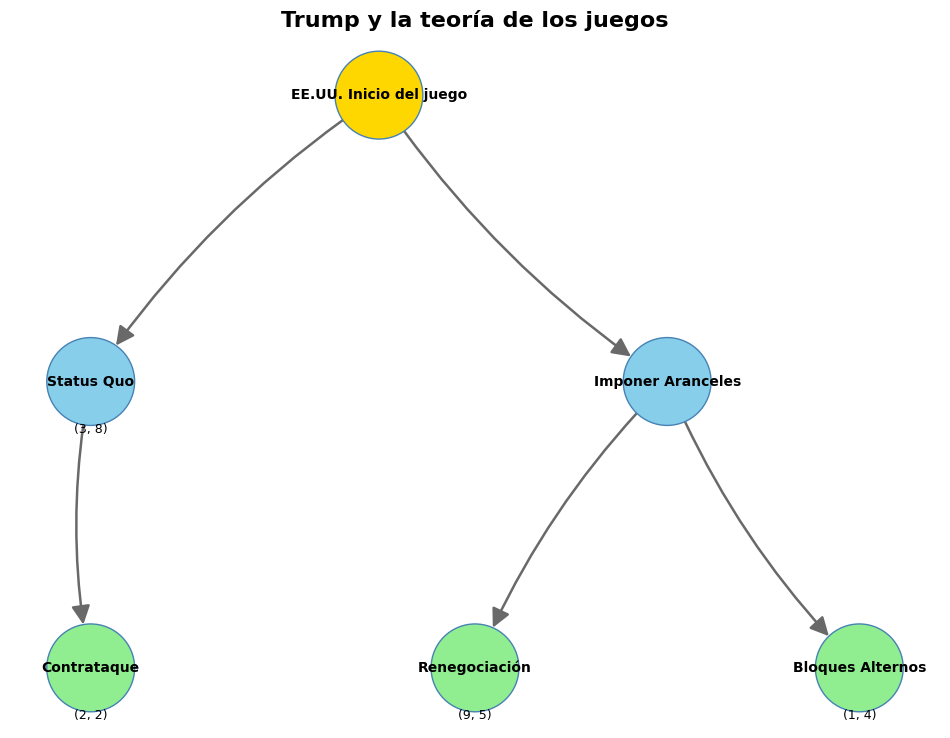


Creando animación con payoffs y colores por nivel...

Preparando GIF (con payoffs)...
GIF guardado como 'arbol_payoffs_niveles.gif'. Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga de GIF iniciada.

Preparando MP4 (con payoffs, lento)...
MP4 guardado como 'arbol_payoffs_niveles.mp4' (a 4 fps). Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga de MP4 iniciada.

Mostrando previsualización HTML final:


In [ ]:

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML, display
import math
from google.colab import files

# --- Configuración del Grafo con Payoffs ---
G_payoffs = nx.DiGraph()

# Ajustar posiciones para mejor espaciado y dejar sitio para payoffs
# (Incrementé separación vertical y horizontal donde parecía necesario)
nodes_payoffs = {
    "EE.UU. Inicio del juego": (0, 2.5), # Un poco más arriba
    "Imponer Aranceles": (1.5, 1.25),  # Movido a la derecha y ligeramente abajo
    "Status Quo": (-1.5, 1.25),       # Movido a la izquierda y ligeramente abajo
    "Renegociación": (0.5, 0),        # Debajo de Aranceles
    "Bloques Alternos": (2.5, 0),     # Más a la derecha de Renegociación
    "Contrataque": (-1.5, 0)        # Debajo de Status Quo, alineado con él
}
pos_payoffs = nodes_payoffs # Usar estas posiciones

# Payoffs asociados a los nodos terminales
payoffs = {
    "Status Quo": "(3, 8)",       # Este es terminal en su rama
    "Contrataque": "(2, 2)",     # Terminal
    "Renegociación": "(9, 5)",   # Terminal
    "Bloques Alternos": "(1, 4)" # Terminal
}

edges_payoffs = [
    ("EE.UU. Inicio del juego", "Imponer Aranceles"),
    ("EE.UU. Inicio del juego", "Status Quo"),
    ("Imponer Aranceles", "Renegociación"),
    ("Imponer Aranceles", "Bloques Alternos"),
    ("Status Quo", "Contrataque")
]

G_payoffs.add_nodes_from(nodes_payoffs.keys())
G_payoffs.add_edges_from(edges_payoffs)
root_node_payoffs = "EE.UU. Inicio del juego"

# --- Calcular Niveles de Nodos ---
try:
    node_levels_payoffs = nx.shortest_path_length(G_payoffs, source=root_node_payoffs)
    max_level_payoffs = max(node_levels_payoffs.values()) if node_levels_payoffs else 0
    print(f"Niveles (payoffs) calculados. Máximo nivel: {max_level_payoffs}")
except Exception as e:
    print(f"Error calculando niveles: {e}")
    node_levels_payoffs = {root_node_payoffs: 0}
    max_level_payoffs = 0

# --- Estilos Visuales: Colores por Nivel y Otros ---
level_colors_payoffs = [
    '#FFD700',  # Gold (Nivel 0 - Raíz)
    '#87CEEB',  # SkyBlue (Nivel 1 - Decisiones Intermedias)
    '#90EE90',  # LightGreen (Nivel 2 - Resultados/Payoffs)
    # Añadir más si la estructura crece
]
# Asegurar suficientes colores
while len(level_colors_payoffs) <= max_level_payoffs:
    level_colors_payoffs.append(level_colors_payoffs[-1])

node_border_color = '#4682B4'   # SteelBlue (borde)
node_size = 4000                # Tamaño de nodo, considerar espacio para payoff
edge_color = '#696969'          # DimGray
edge_width = 1.8
arrow_size = 28
arrow_style = '-|>'
font_size_nodes = 10            # Tamaño del nombre del nodo
font_size_payoffs = 9           # Tamaño del texto del payoff
font_weight_nodes = 'bold'
font_color_nodes = 'black'
figure_bg_color = 'whitesmoke'
payoff_y_offset = -0.18          # Cuánto bajar el texto del payoff relativo al nodo

# Crear mapa de colores basado en niveles
color_map_payoffs = [level_colors_payoffs[node_levels_payoffs.get(node, 0)] for node in G_payoffs.nodes()]

# --- Dibujo Estático Mejorado (con colores por nivel y payoffs) ---
def draw_static_payoffs():
    fig_static, ax_static = plt.subplots(figsize=(12, 9)) # Ajustar tamaño si es necesario
    fig_static.patch.set_facecolor(figure_bg_color)

    # Dibujar nodos y aristas
    nx.draw(G_payoffs, pos=pos_payoffs, ax=ax_static, with_labels=False,
            node_color=color_map_payoffs,
            node_size=node_size,
            edgecolors=node_border_color,
            linewidths=1.0,
            edge_color=edge_color,
            width=edge_width,
            arrowsize=arrow_size,
            arrowstyle=arrow_style,
            connectionstyle='arc3,rad=0.1')

    # Dibujar etiquetas de nodos
    nx.draw_networkx_labels(G_payoffs, pos=pos_payoffs, ax=ax_static,
                             font_size=font_size_nodes,
                             font_weight=font_weight_nodes,
                             font_color=font_color_nodes,
                             verticalalignment='center') # Centrado verticalmente en el nodo


    for node, (x, y) in pos_payoffs.items():
        payoff = payoffs.get(node) # Obtener payoff si existe
        if payoff:
            ax_static.text(x, y + payoff_y_offset, payoff, fontsize=font_size_payoffs,
                           ha='center', va='top', color='black', fontweight='medium')

    ax_static.set_title("Trump y la teoría de los juegos", fontsize=16, weight='bold')
    ax_static.axis('off')
    # Ajustar márgenes si los payoffs se cortan (menos probable con va='top')
    # plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
    plt.show()

print("Mostrando gráfico estático con payoffs y colores por nivel:")
draw_static_payoffs()

# --- Animación con Colores por Nivel y Payoffs ---
fig_anim, ax_anim = plt.subplots(figsize=(12, 9))
fig_anim.patch.set_facecolor(figure_bg_color)

ordered_nodes_payoffs = list(G_payoffs.nodes())
ordered_edges_payoffs = list(G_payoffs.edges())
num_frames_payoffs = len(ordered_nodes_payoffs) + len(ordered_edges_payoffs)

def init_anim_payoffs():
    ax_anim.clear()
    ax_anim.set_title("Trump y la teoría de los juegos con Payoffs", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos_payoffs.values()]
    all_y = [p[1] for p in pos_payoffs.values()]
    # Ajustar límites considerando espacio para payoffs
    ax_anim.set_xlim(min(all_x) - 0.5, max(all_x) + 0.5)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)

def update_anim_payoffs(frame):
    ax_anim.clear()
    nodes_to_show = []
    edges_to_show = []
    nodes_to_add_count = min(frame + 1, len(ordered_nodes_payoffs))
    nodes_to_show = ordered_nodes_payoffs[:nodes_to_add_count]

    if frame >= len(ordered_nodes_payoffs):
        edges_to_add_count = min(frame - len(ordered_nodes_payoffs) + 1, len(ordered_edges_payoffs))
        valid_edges_count = 0
        temp_edges = []
        current_edge_index = 0
        while valid_edges_count < edges_to_add_count and current_edge_index < len(ordered_edges_payoffs):
             edge = ordered_edges_payoffs[current_edge_index]
             if edge[0] in nodes_to_show and edge[1] in nodes_to_show:
                 temp_edges.append(edge)
                 valid_edges_count += 1
             current_edge_index +=1
        edges_to_show = temp_edges

    # Dibujar nodos visibles con colores por nivel
    if nodes_to_show:
        visible_color_map = [level_colors_payoffs[node_levels_payoffs.get(node, 0)] for node in nodes_to_show]
        nx.draw_networkx_nodes(G_payoffs, pos=pos_payoffs, nodelist=nodes_to_show, node_color=visible_color_map,
                               node_size=node_size, edgecolors=node_border_color,
                               linewidths=1.0, ax=ax_anim)
        nx.draw_networkx_labels(G_payoffs, pos=pos_payoffs, labels={n: n for n in nodes_to_show},
                               font_size=font_size_nodes, font_weight=font_weight_nodes,
                               font_color=font_color_nodes, ax=ax_anim, verticalalignment='center')

        # Añadir Payoffs para nodos visibles que los tengan
        for node in nodes_to_show:
             payoff = payoffs.get(node)
             if payoff:
                 (x, y) = pos_payoffs[node]
                 ax_anim.text(x, y + payoff_y_offset, payoff, fontsize=font_size_payoffs,
                              ha='center', va='top', color='black', fontweight='medium')

    # Dibujar aristas visibles
    if edges_to_show:
        nx.draw_networkx_edges(G_payoffs, pos=pos_payoffs, edgelist=edges_to_show, edge_color=edge_color,
                               width=edge_width, arrowsize=arrow_size, arrowstyle=arrow_style,
                               ax=ax_anim, connectionstyle='arc3,rad=0.1')

    ax_anim.set_title("Trump , teoría de los juegos y los payoff", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos_payoffs.values()]
    all_y = [p[1] for p in pos_payoffs.values()]
    ax_anim.set_xlim(min(all_x) - 0.5, max(all_x) + 0.5)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)
    ax_anim.patch.set_alpha(0.0)

# Crear la animación
print("\nCreando animación con payoffs y colores por nivel...")
ani_payoffs = FuncAnimation(fig_anim, update_anim_payoffs, frames=num_frames_payoffs, init_func=init_anim_payoffs, interval=400, repeat=False) # Intervalo un poco mayor si hay menos nodos

plt.close(fig_anim) # Cerrar figura para evitar display extra

# --- Guardar la Animación y Descargar Directamente ---

# 1. GIF
print("\nPreparando GIF (con payoffs)...")
gif_filename_payoffs = "arbol_payoffs_niveles.gif"
try:

    ani_payoffs.save(gif_filename_payoffs, writer=PillowWriter(fps=4), dpi=100) # fps más bajo para ver bien
    print(f"GIF guardado como '{gif_filename_payoffs}'. Iniciando descarga...")
    files.download(gif_filename_payoffs)
    print("Descarga de GIF iniciada.")
except ImportError:
    print("\nERROR: Para guardar GIF, necesitas 'pillow'. Ejecuta: !pip install pillow")
except Exception as e:
    print(f"\nOcurrió un error al guardar/descargar el GIF: {e}")

# 2. MP4
print("\nPreparando MP4 (con payoffs, lento)...")
mp4_filename_payoffs = "arbol_payoffs_niveles.mp4"
try:
    # !apt-get install ffmpeg -y
    ani_payoffs.save(mp4_filename_payoffs, writer=FFMpegWriter(fps=4), dpi=150) # fps bajo = lento
    print(f"MP4 guardado como '{mp4_filename_payoffs}' (a 4 fps). Iniciando descarga...")
    files.download(mp4_filename_payoffs)
    print("Descarga de MP4 iniciada.")
except FileNotFoundError:
    print("\nERROR: Para guardar MP4, necesitas 'ffmpeg'. Intenta: !apt-get update && apt-get install ffmpeg -y")
except Exception as e:
    print(f"\nOcurrió un error al guardar/descargar el MP4: {e}")

# Mostrar HTML al final
print("\nMostrando previsualización HTML final:")
html_output_payoffs = HTML(ani_payoffs.to_jshtml())
display(html_output_payoffs)

Levels (payoffs) calculated. Max level: 2
Displaying static graph with payoffs and level colors:


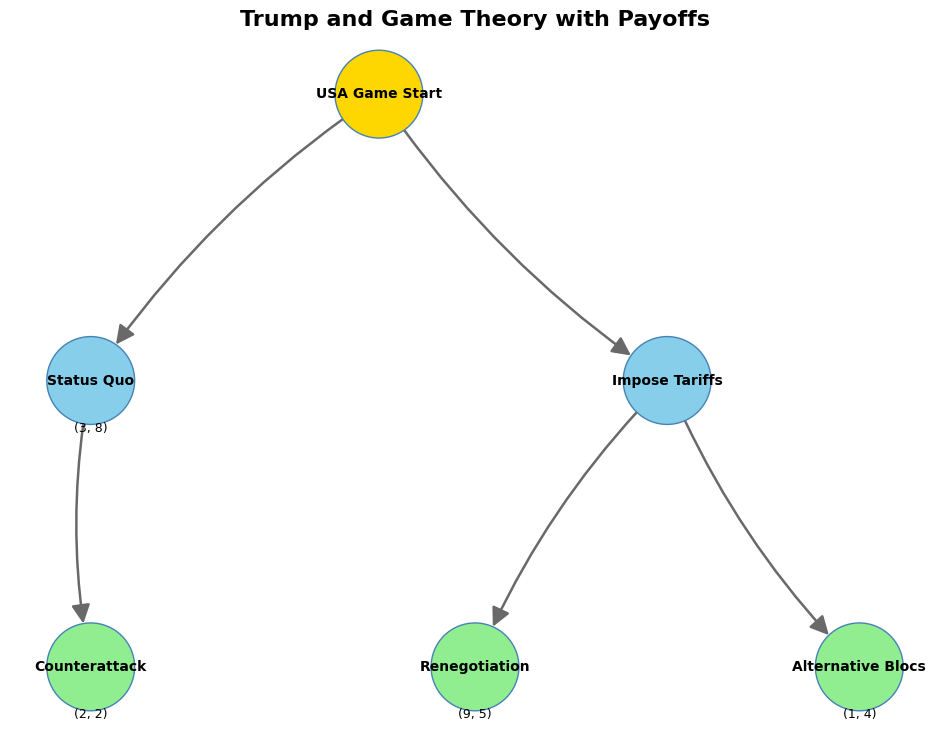


Creating animation with payoffs and level colors...

Preparing GIF (with payoffs)...
GIF saved as 'game_tree_payoffs_levels.gif'. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GIF download initiated.

Preparing MP4 (with payoffs, slow)...
MP4 saved as 'game_tree_payoffs_levels.mp4' (at 4 fps). Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MP4 download initiated.

Displaying final HTML preview:


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML, display
import math
from google.colab import files

# --- Game Tree Configuration with Payoffs ---
G_payoffs = nx.DiGraph()

nodes_payoffs = {
    "USA Game Start": (0, 2.5),
    "Impose Tariffs": (1.5, 1.25),
    "Status Quo": (-1.5, 1.25),
    "Renegotiation": (0.5, 0),
    "Alternative Blocs": (2.5, 0),
    "Counterattack": (-1.5, 0)
}
pos_payoffs = nodes_payoffs

payoffs = {
    "Status Quo": "(3, 8)",
    "Counterattack": "(2, 2)",
    "Renegotiation": "(9, 5)",
    "Alternative Blocs": "(1, 4)"
}

edges_payoffs = [
    ("USA Game Start", "Impose Tariffs"),
    ("USA Game Start", "Status Quo"),
    ("Impose Tariffs", "Renegotiation"),
    ("Impose Tariffs", "Alternative Blocs"),
    ("Status Quo", "Counterattack")
]

G_payoffs.add_nodes_from(nodes_payoffs.keys())
G_payoffs.add_edges_from(edges_payoffs)
root_node_payoffs = "USA Game Start"

try:
    node_levels_payoffs = nx.shortest_path_length(G_payoffs, source=root_node_payoffs)
    max_level_payoffs = max(node_levels_payoffs.values()) if node_levels_payoffs else 0
    print(f"Levels (payoffs) calculated. Max level: {max_level_payoffs}")
except Exception as e:
    print(f"Error calculating levels: {e}")
    node_levels_payoffs = {root_node_payoffs: 0}
    max_level_payoffs = 0

level_colors_payoffs = [
    '#FFD700',  # Gold (Level 0)
    '#87CEEB',  # SkyBlue (Level 1)
    '#90EE90',  # LightGreen (Level 2)
]

while len(level_colors_payoffs) <= max_level_payoffs:
    level_colors_payoffs.append(level_colors_payoffs[-1])

node_border_color = '#4682B4'
node_size = 4000
edge_color = '#696969'
edge_width = 1.8
arrow_size = 28
arrow_style = '-|>'
font_size_nodes = 10
font_size_payoffs = 9
font_weight_nodes = 'bold'
font_color_nodes = 'black'
figure_bg_color = 'whitesmoke'
payoff_y_offset = -0.18

color_map_payoffs = [level_colors_payoffs[node_levels_payoffs.get(node, 0)] for node in G_payoffs.nodes()]

# --- Static Draw with Payoffs ---
def draw_static_payoffs():
    fig_static, ax_static = plt.subplots(figsize=(12, 9))
    fig_static.patch.set_facecolor(figure_bg_color)

    nx.draw(G_payoffs, pos=pos_payoffs, ax=ax_static, with_labels=False,
            node_color=color_map_payoffs,
            node_size=node_size,
            edgecolors=node_border_color,
            linewidths=1.0,
            edge_color=edge_color,
            width=edge_width,
            arrowsize=arrow_size,
            arrowstyle=arrow_style,
            connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G_payoffs, pos=pos_payoffs, ax=ax_static,
                             font_size=font_size_nodes,
                             font_weight=font_weight_nodes,
                             font_color=font_color_nodes,
                             verticalalignment='center')

    for node, (x, y) in pos_payoffs.items():
        payoff = payoffs.get(node)
        if payoff:
            ax_static.text(x, y + payoff_y_offset, payoff, fontsize=font_size_payoffs,
                           ha='center', va='top', color='black', fontweight='medium')

    ax_static.set_title("Trump and Game Theory with Payoffs", fontsize=16, weight='bold')
    ax_static.axis('off')
    plt.show()

print("Displaying static graph with payoffs and level colors:")
draw_static_payoffs()

# --- Animated Graph with Payoffs ---
fig_anim, ax_anim = plt.subplots(figsize=(12, 9))
fig_anim.patch.set_facecolor(figure_bg_color)

ordered_nodes_payoffs = list(G_payoffs.nodes())
ordered_edges_payoffs = list(G_payoffs.edges())
num_frames_payoffs = len(ordered_nodes_payoffs) + len(ordered_edges_payoffs)

def init_anim_payoffs():
    ax_anim.clear()
    ax_anim.set_title("Trump and Game Theory with Payoffs", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos_payoffs.values()]
    all_y = [p[1] for p in pos_payoffs.values()]
    ax_anim.set_xlim(min(all_x) - 0.5, max(all_x) + 0.5)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)

def update_anim_payoffs(frame):
    ax_anim.clear()
    nodes_to_add_count = min(frame + 1, len(ordered_nodes_payoffs))
    nodes_to_show = ordered_nodes_payoffs[:nodes_to_add_count]

    edges_to_show = []
    if frame >= len(ordered_nodes_payoffs):
        edges_to_add_count = min(frame - len(ordered_nodes_payoffs) + 1, len(ordered_edges_payoffs))
        valid_edges_count = 0
        temp_edges = []
        current_edge_index = 0
        while valid_edges_count < edges_to_add_count and current_edge_index < len(ordered_edges_payoffs):
            edge = ordered_edges_payoffs[current_edge_index]
            if edge[0] in nodes_to_show and edge[1] in nodes_to_show:
                temp_edges.append(edge)
                valid_edges_count += 1
            current_edge_index += 1
        edges_to_show = temp_edges

    if nodes_to_show:
        visible_color_map = [level_colors_payoffs[node_levels_payoffs.get(node, 0)] for node in nodes_to_show]
        nx.draw_networkx_nodes(G_payoffs, pos=pos_payoffs, nodelist=nodes_to_show, node_color=visible_color_map,
                               node_size=node_size, edgecolors=node_border_color,
                               linewidths=1.0, ax=ax_anim)
        nx.draw_networkx_labels(G_payoffs, pos=pos_payoffs, labels={n: n for n in nodes_to_show},
                                font_size=font_size_nodes, font_weight=font_weight_nodes,
                                font_color=font_color_nodes, ax=ax_anim, verticalalignment='center')

        for node in nodes_to_show:
            payoff = payoffs.get(node)
            if payoff:
                (x, y) = pos_payoffs[node]
                ax_anim.text(x, y + payoff_y_offset, payoff, fontsize=font_size_payoffs,
                             ha='center', va='top', color='black', fontweight='medium')

    if edges_to_show:
        nx.draw_networkx_edges(G_payoffs, pos=pos_payoffs, edgelist=edges_to_show, edge_color=edge_color,
                               width=edge_width, arrowsize=arrow_size, arrowstyle=arrow_style,
                               ax=ax_anim, connectionstyle='arc3,rad=0.1')

    ax_anim.set_title("Trump, Game Theory and Payoffs", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos_payoffs.values()]
    all_y = [p[1] for p in pos_payoffs.values()]
    ax_anim.set_xlim(min(all_x) - 0.5, max(all_x) + 0.5)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)
    ax_anim.patch.set_alpha(0.0)

print("\nCreating animation with payoffs and level colors...")
ani_payoffs = FuncAnimation(fig_anim, update_anim_payoffs, frames=num_frames_payoffs, init_func=init_anim_payoffs, interval=400, repeat=False)

plt.close(fig_anim)

# --- Save and Download ---
print("\nPreparing GIF (with payoffs)...")
gif_filename_payoffs = "game_tree_payoffs_levels.gif"
try:
    ani_payoffs.save(gif_filename_payoffs, writer=PillowWriter(fps=4), dpi=100)
    print(f"GIF saved as '{gif_filename_payoffs}'. Starting download...")
    files.download(gif_filename_payoffs)
    print("GIF download initiated.")
except ImportError:
    print("\nERROR: To save GIF, install 'pillow'. Run: !pip install pillow")
except Exception as e:
    print(f"\nError saving/downloading GIF: {e}")

print("\nPreparing MP4 (with payoffs, slow)...")
mp4_filename_payoffs = "game_tree_payoffs_levels.mp4"
try:
    ani_payoffs.save(mp4_filename_payoffs, writer=FFMpegWriter(fps=4), dpi=150)
    print(f"MP4 saved as '{mp4_filename_payoffs}' (at 4 fps). Starting download...")
    files.download(mp4_filename_payoffs)
    print("MP4 download initiated.")
except FileNotFoundError:
    print("\nERROR: To save MP4, you need 'ffmpeg'. Try: !apt-get update && apt-get install ffmpeg -y")
except Exception as e:
    print(f"\nError saving/downloading MP4: {e}")

print("\nDisplaying final HTML preview:")
html_output_payoffs = HTML(ani_payoffs.to_jshtml())
display(html_output_payoffs)


Levels calculated. Max level: 4
Displaying static graph with level colors:


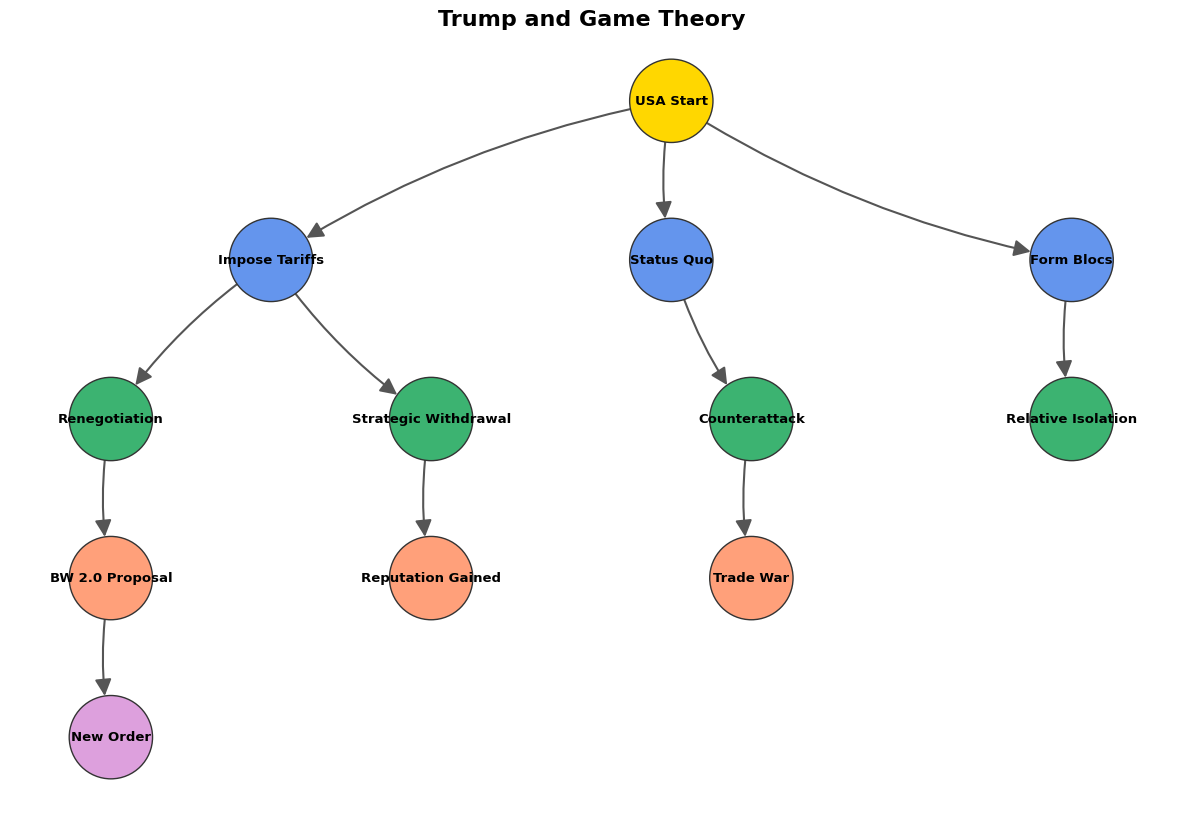


Creating animation with level colors...

Preparing GIF (level colors)...
GIF saved as 'decision_tree_levels.gif'. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GIF download initiated.

Preparing MP4 (level colors, slower)...
MP4 saved as 'decision_tree_levels.mp4' (at 5 fps). Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

MP4 download initiated.

Displaying final HTML preview:


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import HTML, display
import math
from google.colab import files

# --- Graph Configuration ---
G = nx.DiGraph()
nodes_data = {
    "USA Start": (0, 2), "Impose Tariffs": (-2.5, 1), "Status Quo": (0, 1),
    "Form Blocs": (2.5, 1), "Renegotiation": (-3.5, 0), "Strategic Withdrawal": (-1.5, 0),
    "Counterattack": (0.5, 0), "Relative Isolation": (2.5, 0), "BW 2.0 Proposal": (-3.5, -1),
    "Reputation Gained": (-1.5, -1), "Trade War": (0.5, -1), "New Order": (-3.5, -2),
}
node_list = list(nodes_data.keys())
pos = nodes_data
G.add_nodes_from(node_list)
edges = [
    ("USA Start", "Impose Tariffs"), ("USA Start", "Status Quo"), ("USA Start", "Form Blocs"),
    ("Impose Tariffs", "Renegotiation"), ("Impose Tariffs", "Strategic Withdrawal"),
    ("Status Quo", "Counterattack"), ("Counterattack", "Trade War"),
    ("Renegotiation", "BW 2.0 Proposal"), ("BW 2.0 Proposal", "New Order"),
    ("Form Blocs", "Relative Isolation"), ("Strategic Withdrawal", "Reputation Gained")
]
G.add_edges_from(edges)

# --- Compute Node Levels ---
root_node = "USA Start"
try:
    node_levels = nx.shortest_path_length(G, source=root_node)
    max_level = max(node_levels.values()) if node_levels else 0
    print(f"Levels calculated. Max level: {max_level}")
except nx.NetworkXNoPath:
    print("Warning: Not all nodes are reachable from the root.")
    node_levels = {root_node: 0}
    max_level = 0

level_colors = [
    '#FFD700',  # Gold (Level 0 - Root)
    '#6495ED',  # Cornflower Blue (Level 1)
    '#3CB371',  # Medium Sea Green (Level 2)
    '#FFA07A',  # Light Salmon (Level 3)
    '#DDA0DD',  # Plum (Level 4)
]

while len(level_colors) <= max_level:
    level_colors.append(level_colors[-1])

node_border_color = '#333333'
node_size = 3600
edge_color = '#555555'
edge_width = 1.5
arrow_size = 25
arrow_style = '-|>'
font_size_nodes = 9.5
font_weight_nodes = 'bold'
font_color_nodes = 'black'
figure_bg_color = 'whitesmoke'

color_map = [level_colors[node_levels.get(node, 0)] for node in G.nodes()]

# --- Static Drawing ---
def draw_static_improved_levels():
    fig_static, ax_static = plt.subplots(figsize=(15, 10))
    fig_static.patch.set_facecolor(figure_bg_color)

    nx.draw(G, pos, ax=ax_static, with_labels=False,
            node_color=color_map,
            node_size=node_size,
            edgecolors=node_border_color,
            linewidths=1.0,
            edge_color=edge_color,
            width=edge_width,
            arrowsize=arrow_size,
            arrowstyle=arrow_style,
            connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_labels(G, pos, ax=ax_static,
                             font_size=font_size_nodes,
                             font_weight=font_weight_nodes,
                             font_color=font_color_nodes,
                             verticalalignment='center')

    ax_static.set_title("Trump and Game Theory", fontsize=16, weight='bold')
    ax_static.axis('off')
    plt.show()

print("Displaying static graph with level colors:")
draw_static_improved_levels()

# --- Animated Graph ---
fig_anim, ax_anim = plt.subplots(figsize=(15, 10))
fig_anim.patch.set_facecolor(figure_bg_color)

ordered_nodes = list(G.nodes())
ordered_edges = list(G.edges())
num_frames = len(ordered_nodes) + len(ordered_edges)

def init_anim_levels():
    ax_anim.clear()
    ax_anim.set_title("Trump and Game Theory", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax_anim.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)

def update_anim_levels(frame):
    ax_anim.clear()
    nodes_to_show = []
    edges_to_show = []
    nodes_to_add_count = min(frame + 1, len(ordered_nodes))
    nodes_to_show = ordered_nodes[:nodes_to_add_count]

    if frame >= len(ordered_nodes):
        edges_to_add_count = min(frame - len(ordered_nodes) + 1, len(ordered_edges))
        valid_edges_count = 0
        temp_edges = []
        current_edge_index = 0
        while valid_edges_count < edges_to_add_count and current_edge_index < len(ordered_edges):
            edge = ordered_edges[current_edge_index]
            if edge[0] in nodes_to_show and edge[1] in nodes_to_show:
                temp_edges.append(edge)
                valid_edges_count += 1
            current_edge_index += 1
        edges_to_show = temp_edges

    if nodes_to_show:
        visible_color_map = [level_colors[node_levels.get(node, 0)] for node in nodes_to_show]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes_to_show, node_color=visible_color_map,
                               node_size=node_size, edgecolors=node_border_color,
                               linewidths=1.0, ax=ax_anim)
        nx.draw_networkx_labels(G, pos, labels={n: n for n in nodes_to_show},
                                font_size=font_size_nodes, font_weight=font_weight_nodes,
                                font_color=font_color_nodes, ax=ax_anim, verticalalignment='center')

    if edges_to_show:
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_show, edge_color=edge_color,
                               width=edge_width, arrowsize=arrow_size, arrowstyle=arrow_style,
                               ax=ax_anim, connectionstyle='arc3,rad=0.1')

    ax_anim.set_title("Trump and Game Theory", fontsize=16, weight='bold')
    ax_anim.axis('off')
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax_anim.set_xlim(min(all_x) - 1, max(all_x) + 1)
    ax_anim.set_ylim(min(all_y) - 0.5, max(all_y) + 0.5)
    ax_anim.patch.set_alpha(0.0)

print("\nCreating animation with level colors...")
ani = FuncAnimation(fig_anim, update_anim_levels, frames=num_frames, init_func=init_anim_levels, interval=300, repeat=False)

plt.close(fig_anim)

# --- Save and Download ---
print("\nPreparing GIF (level colors)...")
gif_filename = "decision_tree_levels.gif"
try:
    ani.save(gif_filename, writer=PillowWriter(fps=5), dpi=100)
    print(f"GIF saved as '{gif_filename}'. Starting download...")
    files.download(gif_filename)
    print("GIF download initiated.")
except ImportError:
    print("\nERROR: To save GIF, you need 'pillow'. Run: !pip install pillow")
except Exception as e:
    print(f"\nError saving/downloading GIF: {e}")

print("\nPreparing MP4 (level colors, slower)...")
mp4_filename = "decision_tree_levels.mp4"
try:
    ani.save(mp4_filename, writer=FFMpegWriter(fps=5), dpi=150)
    print(f"MP4 saved as '{mp4_filename}' (at 5 fps). Starting download...")
    files.download(mp4_filename)
    print("MP4 download initiated.")
except FileNotFoundError:
    print("\nERROR: To save MP4, you need 'ffmpeg'. Try: !apt-get update && apt-get install ffmpeg -y")
except Exception as e:
    print(f"\nError saving/downloading MP4: {e}")

print("\nDisplaying final HTML preview:")
html_output = HTML(ani.to_jshtml())
display(html_output)
